# Common spatial patterns

> A serious attempt at all the assignments is mandatory to grant access to the final exam. Refer to the course manual for more details (section *Overview* on Brightspace). 

> Please add today's topic to your knowledge graph.

**Learning goals:**
- Get familiar with the MNE toolbox for analysis and decoding of neural oscillations using CSP;
- Understand common spatial patterns (CSP).

**Solutions file:**

For this assignment, a solutions file will be released after the deadline.

**Note:**
In providing your answers to the questions, please denote which question you are providing an answer to (either in text or code) by commenting it with something like "Exercise 1.1" and "Exercise 3.4". This improves readability of your solutions as well as the quality of the feedback you will get.


## Top-down view onto this notebook
In this notebook you will perform an EEG analysis using common spatial patterns (CSP), i.e., determining an oscillatory linear subspace that is informative about a *binary* class label. Typical applications of CSP in the field of brain-computer interfaces use it as a supervised preprocessing/feature-extraction step to extract an oscillatory component, whose band power is informative to discriminate two classes of for instance motor data (e.g., imagery, executed, or attempted execution). In this assignment, you will use a motor imaginary dataset, and will use CSP and LDA to classify whether left or right movement was imagined.

Before diving into the details, it is recommended to:
- familiarize yourself with CSP by reading [Blankertz et al.](https://ieeexplore.ieee.org/document/4408441);
- familiarize yourself with MNE's CSP implementation by going through its hands versus feet decoding tutorial, see [this link](https://mne.tools/stable/auto_examples/decoding/plot_decoding_csp_eeg.html);
- in order to understand the difference between filters and patterns, please be referred to [Haufe et al.](https://www-sciencedirect-com.ru.idm.oclc.org/science/article/pii/S1053811913010914)


The data we will be using in this assignment stems from an motor imaginary (MI) task in which the subject was instructed to perform left hand, right hand or foot MI according to letter cues which where presented on the screen (approx. every 8s). For this assignment we will only focus on the two hand MI groups. The sampling frequency of the setup was 1000 Hz with 64 channels of EEG being recorded. Please do not publish or (re)distribute this data, it is only for teaching purposes! 

This assignment will guide you through the following:
1. In exercise 1, you will rehearse your theoretical background about CSP;
1. In exercise 2, you will download the dataset and setup your environment;
1. In exercise 3, you will investigate the paradigm structure and associated markers;
1. In exercise 4, you will define a subset of channels suitable for decoding MI;
1. In exercise 5, you will perform slice the data into epochs and performing ourlier removal;
1. In exercise 6, you will learn how to fit a CSP spatial filter and investigate the resulting patterns;
1. In exercise 7, you will perform classification ('Left' vs 'Right') with CSP and LDA, optimize the CSP hyper parameters, and you will visualize the temporal and spectral properties of the spatial components;
1. In exercise 8, you will dive deeper into the components of CSP by inspecting the eigenvalue spectrum and learn about so-called "CSP-pairs";
1. In exercise 9 (optional), you implement your own CSP algorithm.

In [4]:
import mne
from scipy.linalg import eig
from scipy.signal import periodogram, hilbert
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.model_selection import StratifiedKFold, cross_val_score
from mne.decoding import CSP
import numpy as np
import yaml

from pathlib import Path

mne.set_log_level('WARNING')

np.random.seed(42)

## Exercise 1: Core theoretical concepts of CSP
The lecture and the three sources above should have provided you with a good overview of the CSP algorithm and its underlying mathematical optimization problem. Try to answer the following questions to rehearse your understandig of the basic concepts.

**Assumptions**:
A EEG data recording is given, assume this data is in $\mathbf{\hat{X}} \in \mathbb{R}^{N_e \times N_c \times N_t}$, with $N_e$ being the number of epochs recorded under a given task, $N_c$ being the number of channels and $N_t$ being the number of recorded samples.

Assume furthermore that you are given labels for each epoch $\mathbf{y} \in \{1, 2\}^{N_e}$ and that you can thus partition the data according to their epoch label into $\mathbf{\hat{X}}_1 \in \mathbb{R}^{N_{e1} \times N_c \times N_t}$ and $\mathbf{\hat{X}}_2 \in \mathbb{R}^{N_{e2} \times N_c \times N_t}$. Where $N_{e1}$ and $N_{e2}$
 are the number of epochs within the classes 1 and 2.

**Questions**:
1. Please write down the optimization equation and describe all variables that you need to introduce, including a description of their dimensions.
2. In your own words, please describe the goal of the above optimization problem.
3. Consider a forward and a backward model. How could you interpret a single filter and the according patterns with regards to those models? Refere to the [Haufe et al.](https://www-sciencedirect-com.ru.idm.oclc.org/science/article/pii/S1053811913010914).
4. Why would one look at patterns instead of filters for a spacial interpretion of what CSP has learned?

1.1 The optimization equation is the following: 

                    w^T Σ1 - Σ2 w                        w^T Σ1 w
       w* =  argmax -------------    or alternatively   -----------
                w   w^T Σ1 + Σ2 w                        w^T Σ2 w 

where, w = spatial filter vector (Nc * 1)

Σ1 = covariance matrix for class 1 (Nc * Nc)

Σ2 = the same but for class 2 (Nc * Nc)

w^T = the transpose of the filter vector  

1.2 The goal of the CSP is to find the spatial filters that transform the data from two different conditions so that their variance becomes as distinct as possible. This makes it so we can get the features that help us separate the two classes to make it easier to indentify what the participant was doing during the EEG scan.

1.3
Forward model: In the forward model, we try to locate the sensor space where the activity came from. The patterns we use reflect the contribution that every channel has on the component and is easier to filter spacially. 
Backward model: In the backward model on the other hand we use the filter that is created by the CSP to filter the difference between all the components. This makes it so that a backward model is used for classification and the forward model is used for locating the sources, which is all needed for correct interpretation in neuroimaging studies, according to Haufe et al. (2014) So, in conclusion:

* CSP filters are optimized for decoding (mix of sources, not interpretable).
* CSP patterns reflect how each sensor contributes to the recovered component → interpretable.

1.4
Patterns directly show which sensors are used for capturing the differences between classes. Filters on the other hand just classify and may mix signals that are not easy to decypher making it hard to get a spatial map out of them.


## Exercise 2: Download, setup, and load the raw data
In this notebook, it is assumed that the files have already been imported from the raw
BrainVision files to so-called *fif* files native to the MNE library. If you want to read up on how to do this, check [this link](https://mne.tools/dev/auto_tutorials/io/plot_20_reading_eeg_data.html).

1. Retrieve the data from BrightSpace and store it at a convenient location locally;
1. load the data by pointing `data_dir` to where you stored the `*.fif` files;

Note: No question here - just setup your environment so you can import the data

In [5]:
data_dir = Path('./assignment_09/data') # I changed ./data to this since unzipping the given .zip gave a folder in a folder
calibration_header = list(data_dir.rglob('calib_*.fif'))[0]
raw = mne.io.read_raw(calibration_header, preload=True)

print("Number of channels:", len(raw.ch_names))
print("Sample frequency:", raw.info["sfreq"], "Hz")
print(raw.info)

Number of channels: 58
Sample frequency: 100.0 Hz
<Info | 12 non-empty values
 bads: []
 ch_names: Fp1, Fp2, AF3, AF4, F7, F5, F3, F1, Fz, F2, F4, F6, F8, FT7, ...
 chs: 58 EEG
 custom_ref_applied: False
 description: Anonymized using a time shift to preserve age at acquisition
 dig: 61 items (3 Cardinal, 58 EEG)
 experimenter: mne_anonymize
 file_id: 4 items (dict)
 highpass: 0.0 Hz
 lowpass: 50.0 Hz
 meas_date: 2000-01-01 00:00:00 UTC
 meas_id: 4 items (dict)
 nchan: 58
 projs: []
 sfreq: 100.0 Hz
>


## Exercise 3: Investigate the markers and set meaningfull names
Next we will have a look at the markers within the loaded `raw` object in order to understand more about the paradigm
structure. For the `mne.io.BaseRaw` object (`raw`) which we loaded above, this information can be found in the `annotations`.

**Question**: 
1. Visualize the marker (i.e. event) distribution
1. What is the maximum time lenght of an epoch we could consider?
1. Is our data set balanced if we cut epochs for `'Left'` and `'Right'`?

In [6]:
# the raw annotations descriptions
mrk = raw.annotations.description

# annotations to events which we later use for epoching
ev, ev_ids = mne.events_from_annotations(raw)

# specify our markers for left/right, the way they where used during the experiment
ev_ids['Left'] = ev_ids.pop('Stimulus/S  1')
ev_ids['Right'] = ev_ids.pop('Stimulus/S  2')
mrk = np.char.replace(np.char.replace(mrk, 'Stimulus/S  1', 'Left'), 'Stimulus/S  2', 'Right')

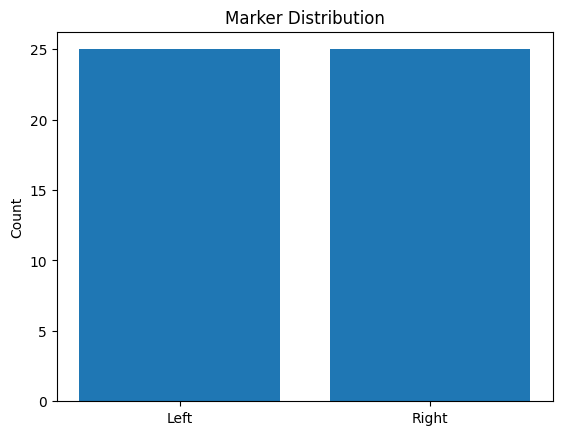

0.9899899999999775


In [7]:
left = np.sum(mrk == 'Left')
right = np.sum(mrk == 'Right')

plt.bar(['Left', 'Right'], [left, right])
plt.title("Marker Distribution")
plt.ylabel("Count")
plt.show()

onsets = raw.annotations.onset
intervals = np.diff(onsets)
print(intervals.min())

3.2  We printed the min() value of the intervals which gave us 0.9899899999999775. This makes it so the maximum possible epoch length is 0.99 seconds since it will include next event material if made longer.

3.3 Yes, since we have 25 left and 25 right events. We can cut epochs the same for both making it a balanced set

## (Optional) Exercise 4: Selecting a channel subset and removing artifacts

Since we are interested in classifying MI, we do know about a very distinct region of interest a priorr, which we will use later to verify the CSP patterns. But since CSP as a machine learning method should be capable of "selecting" relevant channel for the classification task of LEFT vs RIGHT, we will continue with a full channel set.

However there is one crucial constraint, which is when a channel becomes very noisy under one of the conditions. 

Common candidates for such channels are usually in the "temporal" regions (i.e. channels with a T in the name), as the EEG cap is hard to fit tightly to the scalp in those regions. Also frontal channels might include quite some ocular noise. 


**Question**:
1. Plot the STD per channel to find channels with supposedly high noise? Why would you want to highpass filter befor plotting though?

1. Have a look at the channels and their PSDs. What do you see in the spectra and what might it be caused by? 

1. Why would including such channels be especially hazardous for decoding via CSP?


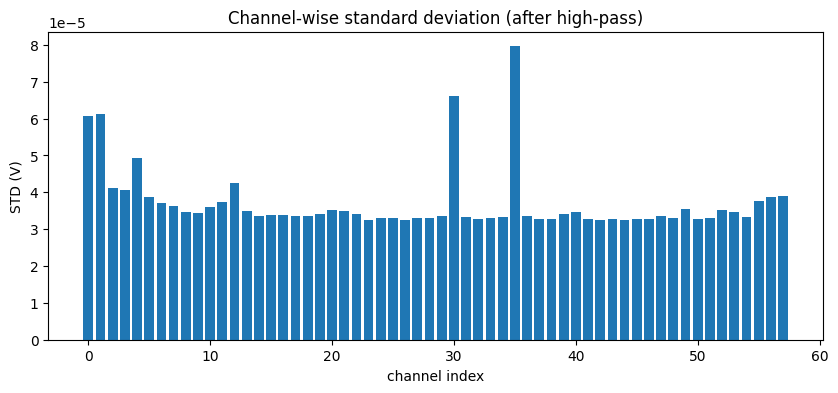

In [8]:
# Answer here
# High-pass to remove slow drifts before computing STD
raw_hp = raw.copy().filter(l_freq=1., h_freq=None)

data = raw_hp.get_data()            # shape: (n_channels, n_times)
ch_std = data.std(axis=1)           # STD per channel

plt.figure(figsize=(10,4))
plt.bar(np.arange(len(ch_std)), ch_std)
plt.xlabel("channel index")
plt.ylabel("STD (V)")
plt.title("Channel-wise standard deviation (after high-pass)")
plt.show()



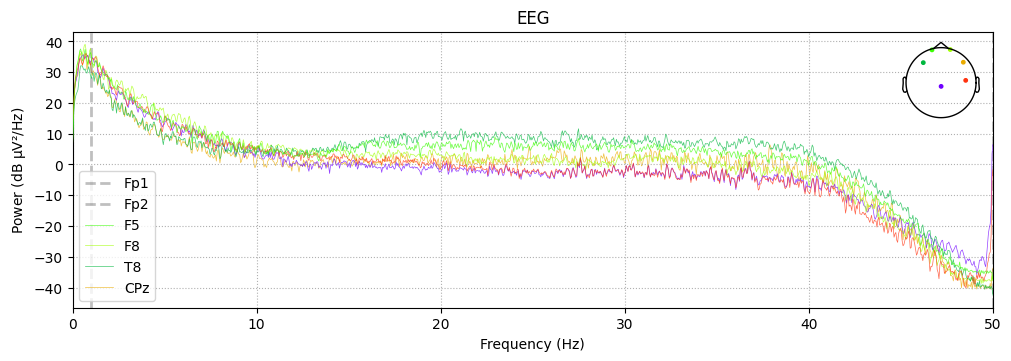

In [31]:
fig = raw_hp.plot_psd(
    fmax=50,
    picks=[0, 1, 5, 12, 30, 35],
    show=False,       # prevent auto-show so we can modify plot
)

ax = fig.axes[0]

# Add legend with channel names
ch_names = [raw_hp.ch_names[i] for i in [0, 1, 5, 12, 30, 35]]
ax.legend(ch_names, loc='lower left')
plt.show()


1. Raw EEG has slow drifts (electrode impedance changes, sweat, movement, DC offsets) so high-passing before plotting is to ignore really low frequency below 1 and remove their contribution.

2. Some of them can be seen having large peaks on 50 Hz that represent the power line noise. In general though, they don't follow the 1/f spectrum shape that they should and have some irregular bumps.

3. If the noisy channels are included  in the CSP, the method will focus on these since they will cause the highest contrast between classes and will miss read class differences caused by physiological motor-related activity. This will lead to overfitting and misleading spatial pattern.

## Exercise 5: Data segmentation ("epoching") and outlier removal

In a standard CSP decoding framework, data is typically cleaned from high amplitude artifacts before proceeding with the analysis. This means that trials (also called epochs) are scanned for large variations in amplitude. Epochs in which the peak-to-peak amplitude of any EEG channel surpasses a predefined min-max threshold criterion
(usually a range above, e.g., 60µV or 80µV is considered an artifact) typically are excluded from further
analysis.

In our specific case, we will have epochs which are rather longer than epochs of other BCI paradigms. For the sake of this excercise we do not need to be too strict with those peak-to-peak values.


**Questions**:
1. Why do we need a highpass filter if we are slicing epochs with a peak-to-peak rejection?
1. Find a reasonable value for `YOUR_MAX_P2P` such that ~15 epochs will be dropped and plot an epochs image to verify, that epochs are sufficiently homogeneous in terms of amplitudes.
1. **Optional**: Why do we apply frequency filters always on the raw and not on the epoched data? 

Total number of epochs initially: 50
Number of epochs dropped due to artifacts (min-max):  14


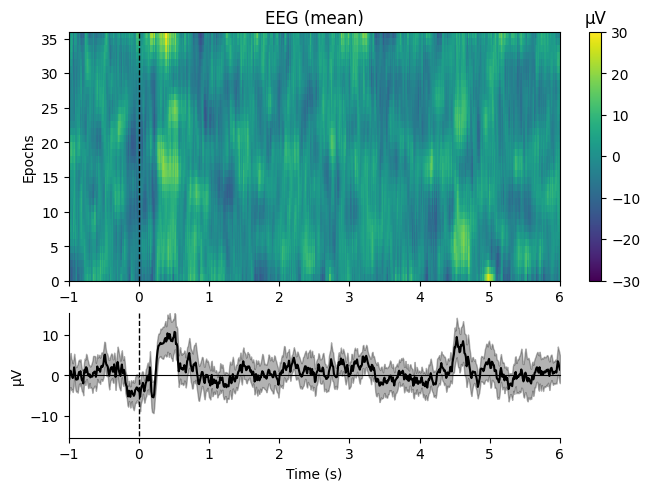

[<Figure size 640x480 with 3 Axes>]

In [28]:
# Read events (i.e., markers)
# Epoch data
YOUR_MAX_P2P = 138*10**-6
drop_channels = ['Fp1', 'Fp2', 'T8', 'CPz', 'F8', 'AF3', 'AF4', 'F7', 'F5', 'F6', 'F3', 'F4']
sraw = raw.copy().pick_channels([r for r in raw.ch_names if r not in drop_channels])

# we create a function as we will use the epoch creation for our events later again
def get_epochs(selected_raw, max_p2p=YOUR_MAX_P2P):
    # use ev and ev_id from above
    sev = ev[np.isin(ev[:, 2], [ev_ids['Left'], ev_ids['Right']]), :]
    epo = mne.Epochs(selected_raw, sev, event_id={'Left': ev_ids['Left'], 'Right': ev_ids['Right']}, 
                     tmin=-1, tmax=6, preload=True, 
                     reject=dict(eeg=max_p2p), reject_tmin=-1
                    )
    epo.drop_bad()
    return epo

epo = get_epochs(sraw.filter(1, 40))     


# Get which epochs were dropped due to artifacts - note the epo.drop_log is a list of tuples for all
# epochs as defined by the events we defined ('ev'). Out of those quite a few where dropped due to the peak-to-peak amplitude
ix_good = [i for i, reason in enumerate(epo.drop_log) if reason == ()]
print(f"Total number of epochs initially: {len(epo.drop_log)}")
print("Number of epochs dropped due to artifacts (min-max): ", len(epo.drop_log) - len(ix_good))

epo.plot_image(picks='eeg', combine='mean', sigma=2, cmap='viridis')

1) We need a highpass filter to remove those large high amplitude artifacts from the data. There are still instances of signal distortions that can pass through the peak-to-peak rejection which can be removed with the filter. Especially with longer epochs it is important to have a highpass filter otherwise some epochs might not get rejected even though they should be.
2) The amplitudes are not perfectly homogeneous but we could not get it better than this.
3) Raw data gives way better temporal context than epoched data, and is much easier/faster to compute because the filter can just be applied once over the whole raw data.

## Exercise 6: Fitting CSP
The most crucial prerequisite for CSP is that it is only suitable for narrow band filtered data. But for our data set, we do not yet know which band would be the best in terms of the final classification performance. A first indication can be gained by visually inspecting the psds for the two classes sperately. 

Look at the PSD plot down below and define frequency ranges which could be good candidates for classifying `'Left'` from `'Right'`.

Afterwards you will find an example of how CSP can be trained and how one could look at the trained patterns.

**Questions**:
1. Given the PSD, which frequency bands would you have a look at?
1. Try out a few frequency bands and plot the resulting patterns. What do you make of the plots with respect to you initial range selection?

**Note**: As CSP is a supervised method, we are probably overfitting CSP. In terms of analyzing the patterns, we could use crossvalidation and then analyze the patterns for each fold individually. This analysis is sometimes interesting for assessing the stability of components accross the folds / the session (if using a chronological split), but takes longer. Furthermore, it is also more difficult to maintain an overview of the patterns. So for our purpose, we will look at patterns alwasys on CSPs trained with all data we have. Doing it with a bit of overfitting is not critical, just keep in mind that this is happening.


**Optional**: Performing cross-validation simply by using `stratifiedKfold` on the full epoch set has a potential issue for physiological data. Provided with the information, that certain CSP patterns might change due to non-stationary processes (e.g. circadian rythm), what could be the problem with simply using `stratifiedKfold`?



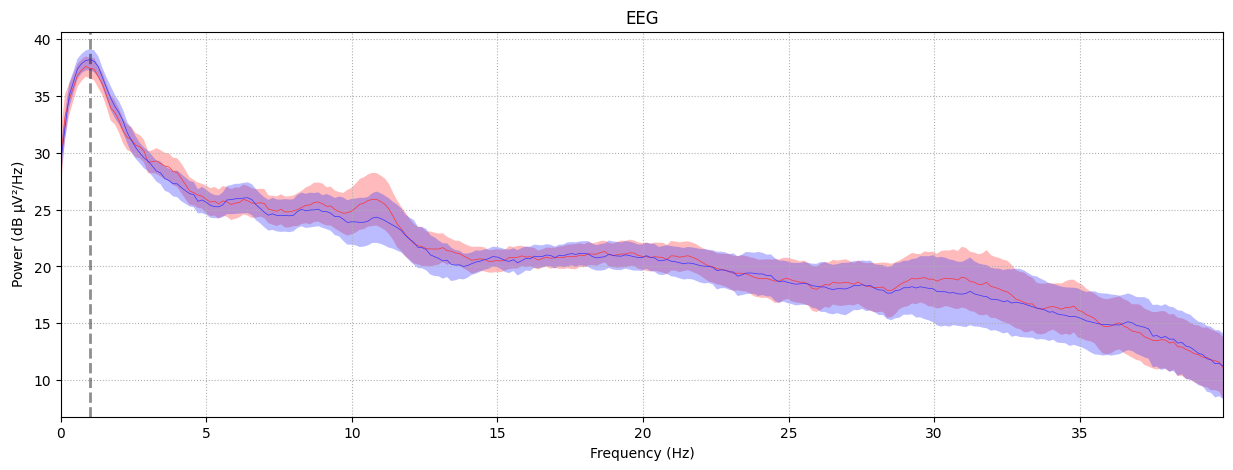

In [32]:
# First indication from PSD
fig, ax = plt.subplots(1, 1, figsize=(15, 5))

for i, (direction, clr) in enumerate(zip(['Left', 'Right'], ['#ff3333', '#3333ff'])):
    epo[direction].plot_psd(ax=ax, show=False, average=True, spatial_colors=False, color=clr, fmax=40)
fig
print()

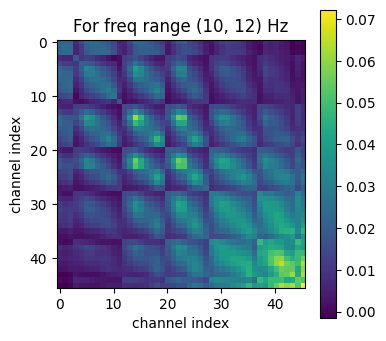

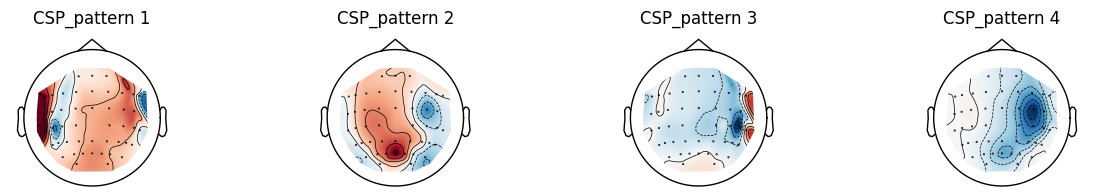

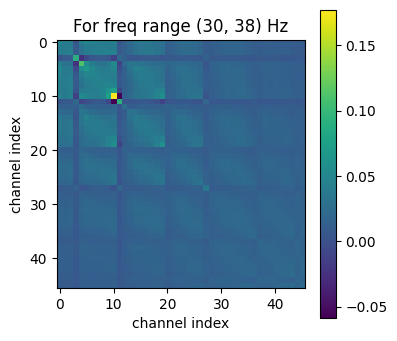

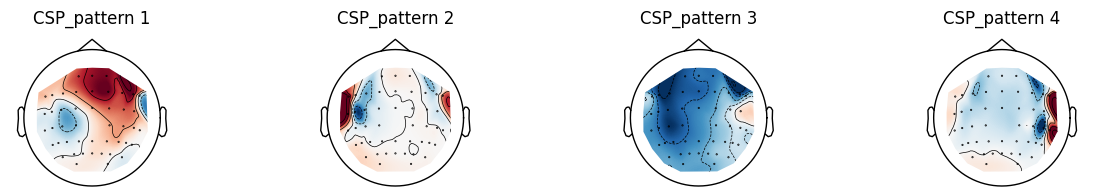

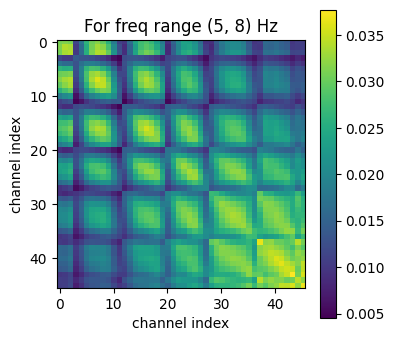

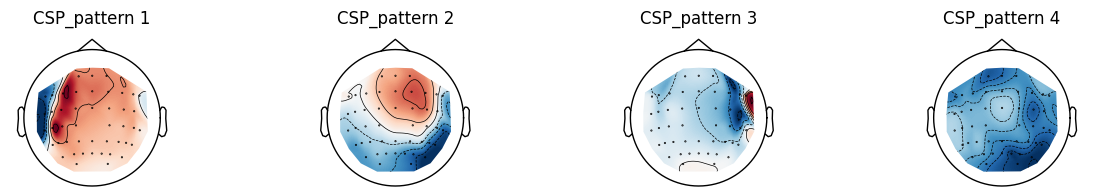

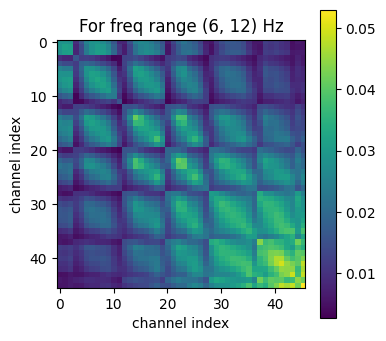

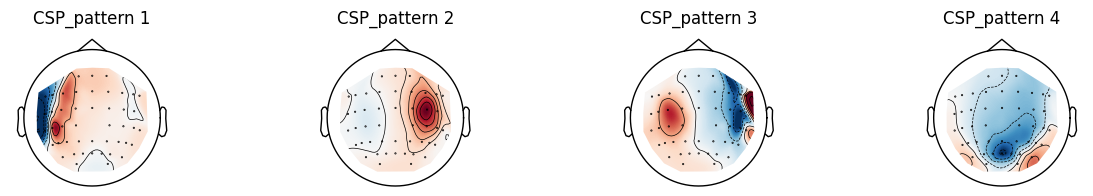

In [33]:
# Try out different filter ranges (~ 2 - 8 Hz in width) and plot the topo plots. Also assess which range you would use.
# frange = (10, 12)  # best
# frange = (30, 38)
# frange = (6, 12)
# frange = (5, 8)
# frange = (3, 8)  # theta band
franges = [(10, 12), (30, 38), (5, 8), (6, 12)]

for frange in franges:
    # Copy epoch
    epo_training = get_epochs(sraw.copy().filter(*frange))     # remember to copy, else your raw would be filtered
    labels = [0 if 'Left' in epo_training[i].event_id.keys() else 1 for i, _ in enumerate(epo_training)]

    # Time interval
    time_interval = (0, 4)  # in seconds
    epo_training.crop(*time_interval)

    # Extract data
    epochs_data_train = epo_training.get_data()

    # Note: a computational trick -> adding a minimal amount of noise for numeric stability.
    # comment this out and try for yourself
    # epochs_data_train += np.random.randn(*epochs_data_train.shape) * 10**-12

    # Build CSP features
    n_components = 4
    csp = CSP(n_components=n_components, reg=None, log=True, norm_trace=False, component_order='alternate')
    csp.fit(epochs_data_train, labels)

    # Compute empirical covariance matrix in the target frequency band
    data_concat =  np.hstack(epochs_data_train)    # stacked by time dimension
    cov = np.dot(data_concat, data_concat.T)
    cov = cov/np.linalg.norm(cov, 'fro')  # this scaling is not necessary, but color range of plots may be more adequate

    # Visualize the covariance matrix
    fig, ax = plt.subplots(1,1,figsize=(4, 4))
    pos = ax.imshow(cov, interpolation='none')
    fig.colorbar(pos, ax=ax)
    ax.set_xlabel('channel index')
    ax.set_ylabel('channel index')
    ax.set_title(f"For freq range {frange} Hz")
    
    # Visualize CSP patterns
    fig, ax = plt.subplots(1, n_components, figsize=(15, 2))
    for i in range(n_components):
        mne.viz.plot_topomap(csp.patterns_[i, :], epo_training.info, axes=ax[i], show=False, extrapolate='local')
        ax[i].set_title(f"CSP_pattern {i + 1}")
    fig;

### Answer here
1. The possible bands that show promise in the PSD are primarily the alpha band from 8 Hz to 12 Hz (specifically 10-12 Hz) and then possibly the start of the gamma band as well as some of the theta band.

2. Checking the plotted patterns of these frequencies we see that in spite of expecting highest covariance between classes in the alpha frequency band 10 - 12 Hz we do not observe that. The highest covariance is achieved with the theta frequency ranges although the locations is not accurate to contralateral arm movement. It does have howerver a better representation of the brain location/region.

## Exercise 7: Binary classification using CSP and LDA

Finally, you get to the actual work. We will now investigate the decoding capabilities of features extracted with CSP regarding the MI state. 

Your first task will be to implement a pipeline which provides `accuracy` as an outcome score if used with a cross validation like `cross_val_score(...)`. 

As stated above, we do not know a priori which frequency band will give us the best decoding performance, although since we are dealing with motor related processes, the beta range would be a good starting point. A more fine grain frequency band can be found by a simple brute force grid search.

Finally we will look at the decoding performance along the time dimension of the epochs. If our decoder is indeed able to decode the task of MI for `'Left'` or `'Right'` hand movement, we would assume that the performance is somehow aligned to the task onset.

**Questions**:
1. Build a classifier using the example in the next cell;
1. (Optional) Perform a gridsearch to find optimal frequency bands for the decoding - look at a range from 2 - 30 Hz and make the ranges at least 1Hz wide. Do not over do it ~ 100 tested bands should suffice. Then use the result as your `OPTIMAL_BAND`.
1. Assuming your pipeline consists of a CSP spatial filter + an LDA classifier. What would be the input to the LDA. Have a look at the plots of the last cell for this exercise. What does `A` in the last code cell represent?

In [72]:
OPTIMAL_BAND = (12, 30) #good accuracy scores for bands: 3,24 to 3,30; 6,25 to 6,30; 7,25; 8,12; 8,26 to 8,30; 12,29 and 12,30
epo = get_epochs(sraw.copy().filter(*OPTIMAL_BAND))
labels = np.asarray([0 if 'Left' in epo[i].event_id.keys() else 1 for i, _ in enumerate(epo)])

epo.crop(1, 4)

X = epo.get_data()
cv = StratifiedKFold(5)

clf = Pipeline(steps = [
    ("csp", CSP(n_components=4, reg=None, log=True, norm_trace=False, component_order='alternate')), 
    ("lda", LDA())
    ]
)

scores = cross_val_score(clf, X, labels, cv=cv)
print(f"{scores=}")
print(f"{np.mean(scores)=:.2%}")

scores=array([1.        , 1.        , 0.7       , 0.9       , 0.66666667])
np.mean(scores)=85.33%


In [73]:
## Looking at the sliding performance of the classifier
def calc_running_score(clf, epo, labels, wstart=0, wend=6, wsize=raw.info['sfreq'] / 2):
    """ 
    Perform classification with a sliding window
    Note: this function assumes clf to have a spatial filter in clf[0] and a final classifier in clf[-1]
    If your clf has more than two steps, you need to adjust this function
    """
    scores = []
    
    wepo = epo.copy().crop(wstart, wend)
    X_all = wepo.get_data()
    start_idx = np.arange(0, X_all.shape[-1], wsize, dtype=int)
    start_idx = start_idx if start_idx[-1] + wsize <= X_all.shape[-1] else start_idx[:-1]  # check if last start would be enough for a full window
    
    for idx in start_idx:
        X_filt = clf[0].transform(X_all[:, :, idx:int(idx + wsize)])
        scores.append(clf[-1].score(X_filt, labels))
    
    return (scores, wepo.times[start_idx])



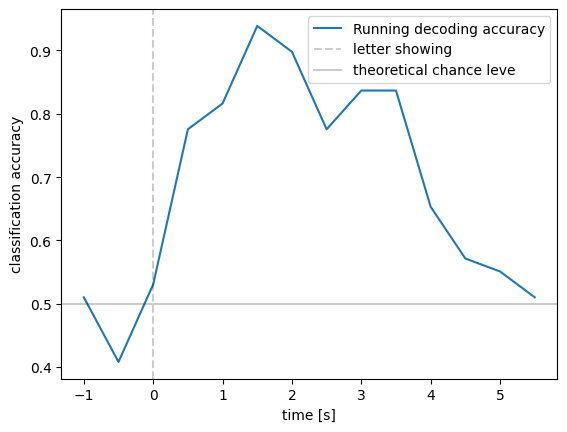

In [74]:
# We fit here on the whole data knowing that this leads to overfitted results, which we ignore for the time being
clf.fit(X, labels)

epo = get_epochs(sraw.copy().filter(*OPTIMAL_BAND))
labels = np.asarray([0 if 'Left' in epo[i].event_id.keys() else 1 for i, _ in enumerate(epo)])

rscores, times = calc_running_score(clf, epo, labels, wstart=-1)
plt.plot(times, rscores, label='Running decoding accuracy')
plt.axvline(0, linestyle='--', color='k', alpha=0.2, label='letter showing')
plt.axhline(0.5, linestyle='-', color='k', alpha=0.2, label='theoretical chance leve')
plt.xlabel('time [s]')
plt.ylabel('classification accuracy')
plt.legend(loc='upper right')
plt.show()

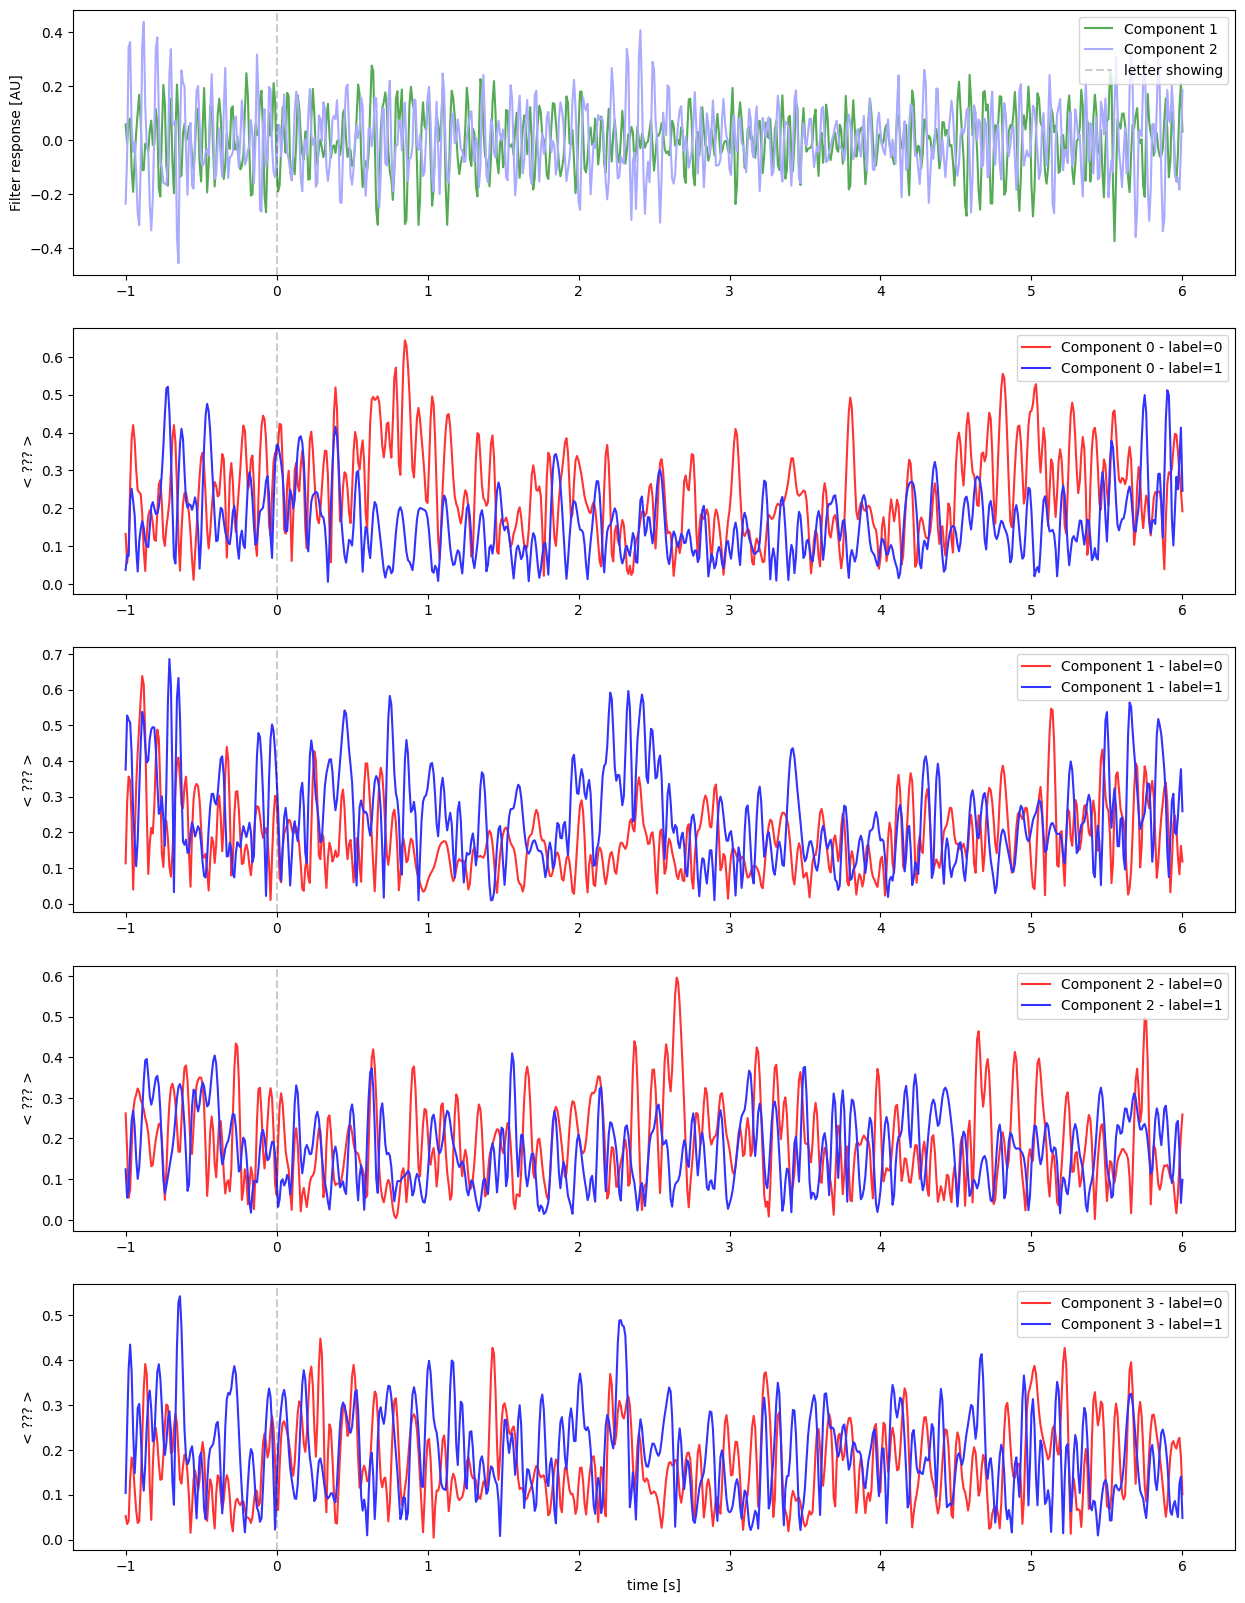

In [75]:
# Try to remember, what would be the input of the final classification step (e.g. LDA)?
# Have a look at the following plots and see how they are linked to the sliding classifier result
epo = get_epochs(sraw.copy().filter(*OPTIMAL_BAND))
X = epo.get_data()

from copy import deepcopy
csp = deepcopy(clf[0])      # to not mess with the trained classifier
csp.transform_into = 'csp_space'
Xcsp = csp.transform(X)

A = [
        np.abs(hilbert(Xcsp[labels == 0].mean(axis=0))),
        np.abs(hilbert(Xcsp[labels == 1].mean(axis=0)))
    ]            # What is this and how does it link to the classifier?

fig, axs = plt.subplots(1 + Xcsp.shape[1], 1, figsize=(15, 20))
axs[0].plot(epo.times, Xcsp.mean(axis=0)[0, :], label='Component 1', color='#5a5')
axs[0].plot(epo.times, Xcsp.mean(axis=0)[1, :], label='Component 2', color='#aaf')
axs[0].axvline(0, linestyle='--', color='k', alpha=0.2, label='letter showing')
axs[0].set_ylabel('Filter response [AU]')
axs[0].legend(loc='upper right')

for i in range(Xcsp.shape[1]):
    axs[i + 1].plot(epo.times, A[0][i, :], color='#f33', label=f"Component {i} - label=0")
    axs[i + 1].plot(epo.times, A[1][i, :], color='#33f', label=f"Component {i} - label=1")
    axs[i + 1].axvline(0, linestyle='--', color='k', alpha=0.2)
    axs[i + 1].set_ylabel('< ??? >')
    axs[i + 1].legend(loc='upper right')
plt.xlabel('time [s]')
plt.show()

3. The y-axis should be absolute filter response [AU]. The plots show the average power changes over time for the CSP components. 

## Exercise 8: CSP components

In this exercise you are going to explore the details of CSP. In many publications you will find the notion of "CSP-pairs". Specifically, the CSP computes maximizes the difference in variance between the two classes, so we seek for components that maximizes the variance for one class, while minimizing the variance for the other class. On the background, the CSP therefore computes a generalized eigenvalue decomposition of the two class-specific covariance matrices. This results into the fact that the first component maximizes the variance of the first class (while minimizing the variance of the second), while the last component captures maximum variance of the second class (while minimizing the first). This might help you to understand the plots above.

It implies that it does not matter what the order of labels is. It is exactly this property that suggests to use CSP-pairs, specifically to select pairs of components in the order: 1 and N, 2 and N-1, 3 and N-2, etc., for N componenets. 

MNE does not allow us to access the eigenvalue directly. Below you can find a `fit_csp()` function that allows you to access the eigenvectors (CSP components) and recalculates the eigenvalues as would be done during the fit of the `CSP` instance. 

Let's investigate this in depth:
1. Fit the CSP to all data (this time using the `fit_csp()` function) and compare the eigenvalues with the CSP filters;
1. Apply the CSP to the data (i.e., project the data into CSP space);
1. Plot the eigenvalue spectrum, and the decoding as a function of number of components used;
1. Repeat the steps above for reversed labels (i.e., label 0 becomes 1 and label 1 becomes 0). 

The output of this analysis should look something like:
<img src="./assignment_09/data/2022-08-30_eigval_and_mean_CV.png"> 

1. Show how eigenvectors and CSP filters relate -> which transformation do you need to perform to map one onto the other?
1. Can you relate the two eigenvalue spectra? Specifically, how does the one map onto the other?
1. Can you relate the accuracy curves? Specifically, how does the one map onto the other?
1. Why do the score curves not have a smooth increase/decrease like the eigenvalues do? Specifically, why is there a U curve? **Hint:** Think about what the CSP optimizes.
1. **Optional:**
The `cross_val_score()` function can implement different scoring metrics. Play around with several.


In [76]:
def fit_csp(data, labels):
    csp = CSP(n_components=data.shape[1], reg=None, log=True, norm_trace=False)
    csp._classes = np.unique(labels)
    covs, sample_weights = csp._compute_covariance_matrices(data, labels)
    eigen_vectors, eigen_values = csp._decompose_covs(covs, sample_weights)
    return eigen_vectors, eigen_values


In [77]:
# Start off here and recreate the plots in the task description - Note: each point corresponds to a single CSP component
epo = get_epochs(sraw.copy().filter(*OPTIMAL_BAND))
labels = [0 if 'Left' in epo[i].event_id.keys() else 1 for i, _ in enumerate(epo)]
rev_labels = [0 if l == 1 else 1 for l in labels]
epo.crop(0.5, 5)

X_all = epo.get_data()

evec, evals = fit_csp(X_all, labels)
evec_r, evals_r = fit_csp(X_all, rev_labels)

cv = StratifiedKFold(n_splits=5)

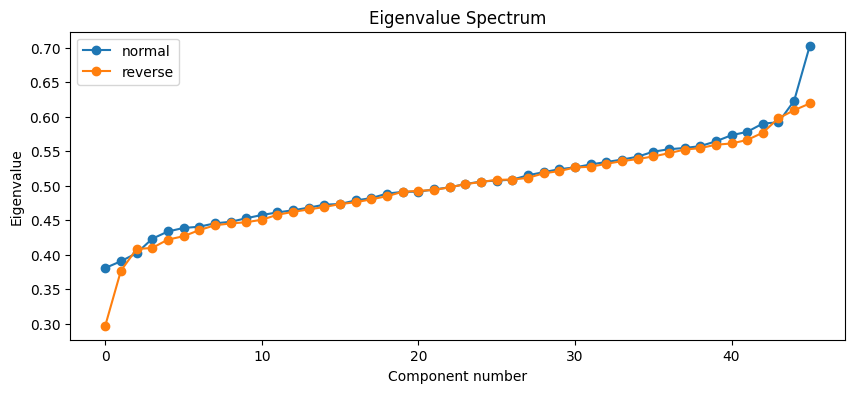

In [78]:
plt.figure(figsize=(10,4))
plt.plot(evals, 'o-', label='normal')
plt.plot(evals_r, 'o-', label='reverse')
plt.title("Eigenvalue Spectrum")
plt.xlabel("Component number")
plt.ylabel("Eigenvalue")
plt.legend()
plt.show()

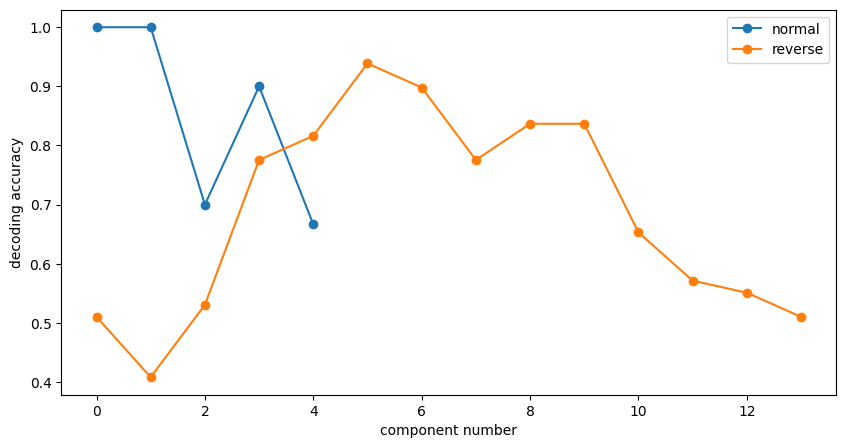

In [81]:
plt.figure(figsize=(10,5))
plt.plot(scores, 'o-', label="normal")
plt.plot(rscores, 'o-', label="reverse")
plt.xlabel("component number")
plt.ylabel("decoding accuracy")
plt.legend()
plt.show()

1) the CSP filters and eigenvectors relate in that eigenvectors are a direct part of the CSP filter. to map one onto another you transform the total covariance by whitening and then mapping back into original space
2) one spectrum is the reverse of the other, in the plot this makes the curve not differ that much, but on the accuracy plot, they should be mirrors of each other. 
3) the accuracy plots we did not figure out properly so its tough to say what the relation is.
4) the 2 plots show different things and while the eigenvalues have a smooth curve, the accuracy does not look at eigenvalues so values can differ greatly.

## (Optional) Exercise 9: Implementing a basic CSP + LDA classifier

Implementing the CSP boils down to performing a generalized eigenvalue decomposition. For this we need the two covariance matrices (i.e., one for each class) that you learned to compute in assignment 02. Subsequently, look up the documentation of scipy's `eig()` (for extra intuition see [Wikipedia](https://en.wikipedia.org/wiki/Eigendecomposition_of_a_matrix)) on how to perform a generalized EVD instead of an ordinary one. Make sure to order the eigenvectors according to the eigenvalues. 

You can use the outputted eigenvectors directly as features for decoding. To do so, project the (band-limited) data to the CSP component space using CSP-pairs: use the first and last, second and one before last, etc. components. Then, either compute the absolute Hilbert transform, or use the squared data as input to an LDA classifier. Note that this is required because the optimization we consider for CSP is optimizing for variance (in CSP space) differences and hence approximately the bandpower of the CPS projection, but not the CSP projections ($\textbf{W}^T\cdot\textbf{X}$) themselves! 

Note, this is the most simple and basic way of getting the CSP. In MNE, several optimizations are implemented. For instance, it keeps track of how many examples are available for each class to weight covariance estimates, it can compute regularized covariance matrices, it can order the componens in alternating way (CSP-pairs) but also according to mutial information, and more. It is likely that your estimates will differ slightly from those of the previous exercise.

**Question:**
1. Build a CSP calculation using only `numpy` functionality.
2. Use the CSP output with an LDA classifier and look at the EV spectrum and CV results as in 8.
3. Compare filters from your CSP algorithm and from a fit of an `mne.CSP` instance.

In [ ]:
# Answer here

## Exercise 0: Who did what?
Please provide a short description on who contributed what to your submission.

> Cas 1, 2, 3

> Petros 1, 4, 6

> Jeroen 4, 7

> Laurens 5, 8